In [1]:
import sys
from pathlib import Path

# Add the nearest parent "src" directory to Python path
src_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()), None)

if src_path is None:
    raise FileNotFoundError("Could not find a 'src' directory in current path or parent directories.")

sys.path.insert(0, str(src_path))
print(f"Added to sys.path: {src_path}")

Added to sys.path: /users/eleves-b/2023/keyvan.attarian/RL_project


In [ ]:
import numpy as np
from tqdm import tqdm
from src.dvn.agent import DVNAgent1P
from src.blockblast.block_blast_env import BlockBlastEnv
from datetime import datetime
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
import torch


In [3]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [33]:
env = BlockBlastEnv(
    punish_for_invalid=-1000
)

In [32]:
agent = DVNAgent1P(device="cuda")
agent.load_model("../checkpoints/dvn_ep_9000.pt")

In [27]:
num_episodes = 100
max_steps_per_episode = 100

In [ ]:
total_returns = []
lengths = []
values = []
rewards = []

for episode in tqdm(range(1, num_episodes + 1), desc="Évaluation"):
    obs, _ = env.reset()
    
    episode_return = 0.0 
    
    for step in range(max_steps_per_episode):
        action = agent.select_action(obs, epsilon=0.01)  # Pas d'exploration pendant l'évaluation
        #rewards = obs["placements_result"][1]
        #action = np.argmax(rewards)
        x = torch.tensor(obs["board"], dtype=torch.float32).unsqueeze(0).to(agent.device)
        values.append(agent.policy_net(x)[0,0].item())
        next_obs, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)
        episode_return += reward
        
        if terminated or truncated:
            break
        
        obs = next_obs
    
    total_returns.append(episode_return)
    lengths.append(step + 1)

Évaluation: 100%|██████████| 100/100 [00:06<00:00, 14.98it/s]


In [48]:
total_returns = np.array(total_returns)
lengths = np.array(lengths)
print(f"Average Return: {total_returns.mean():.2f} ± {total_returns.std():.2f}")
print(f"Average Episode Length: {lengths.mean():.2f} ± {lengths.std():.2f}")

Average Return: 238.80 ± 266.52
Average Episode Length: 36.70 ± 24.83


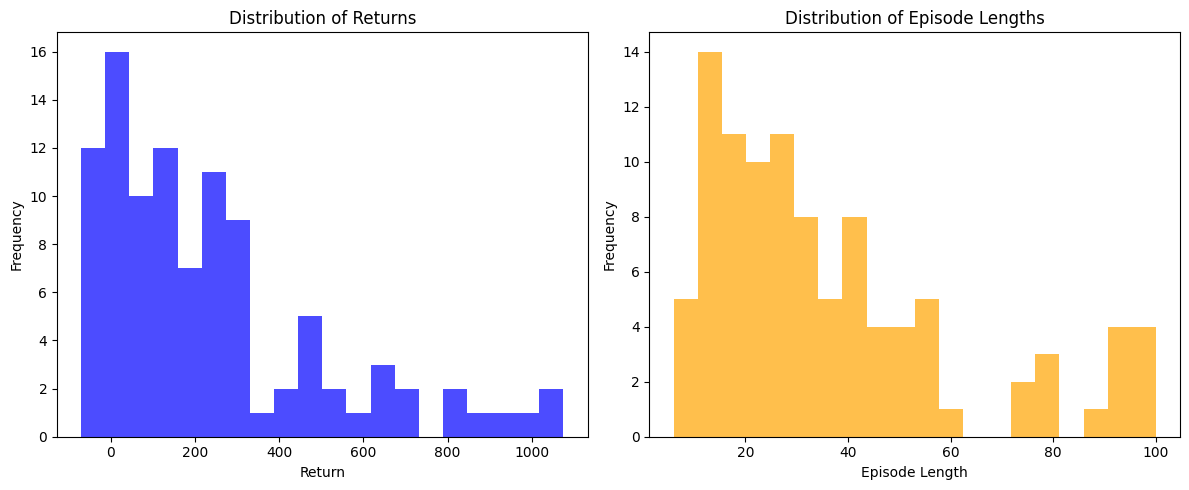

In [49]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(total_returns, bins=20, color='blue', alpha=0.7)
plt.title("Distribution of Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.hist(lengths, bins=20, color='orange', alpha=0.7)
plt.title("Distribution of Episode Lengths")
plt.xlabel("Episode Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

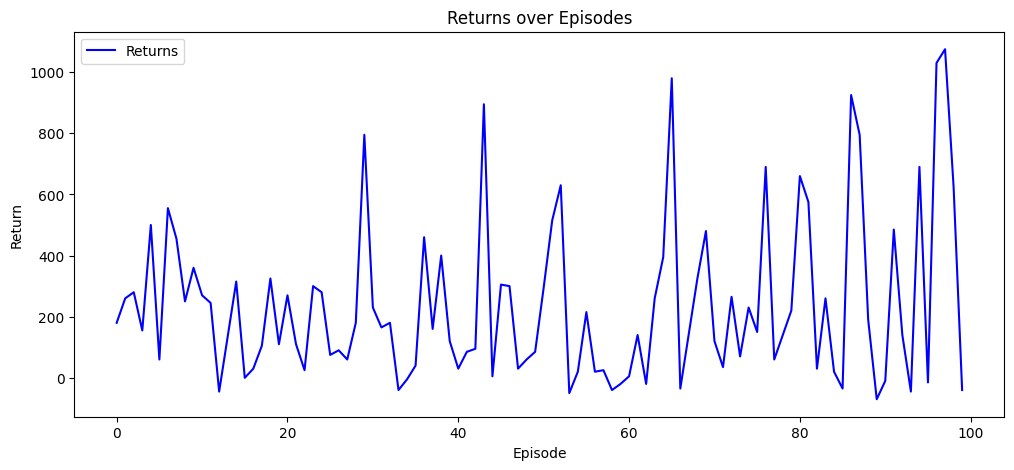

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(total_returns, label="Returns", color='blue')
plt.title("Returns over Episodes")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

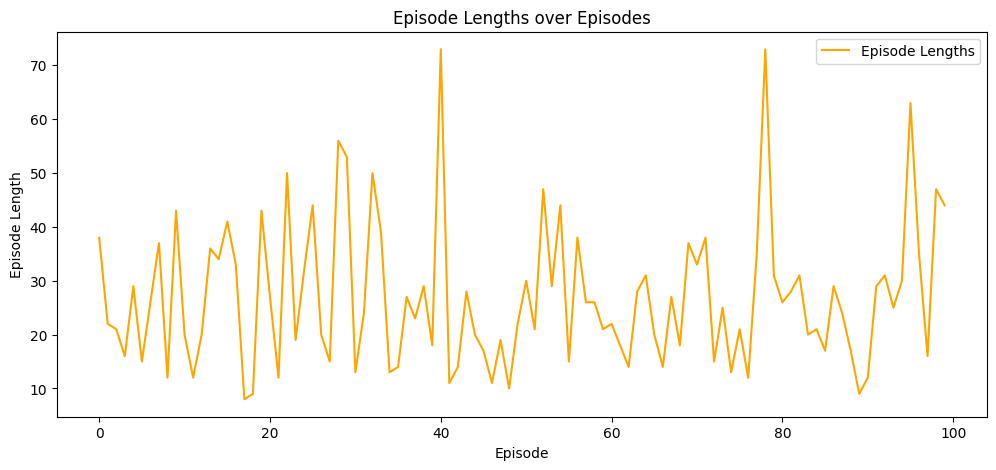

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(lengths, label="Episode Lengths", color='orange')
plt.title("Episode Lengths over Episodes")
plt.xlabel("Episode")
plt.ylabel("Episode Length")
plt.legend()
plt.show()

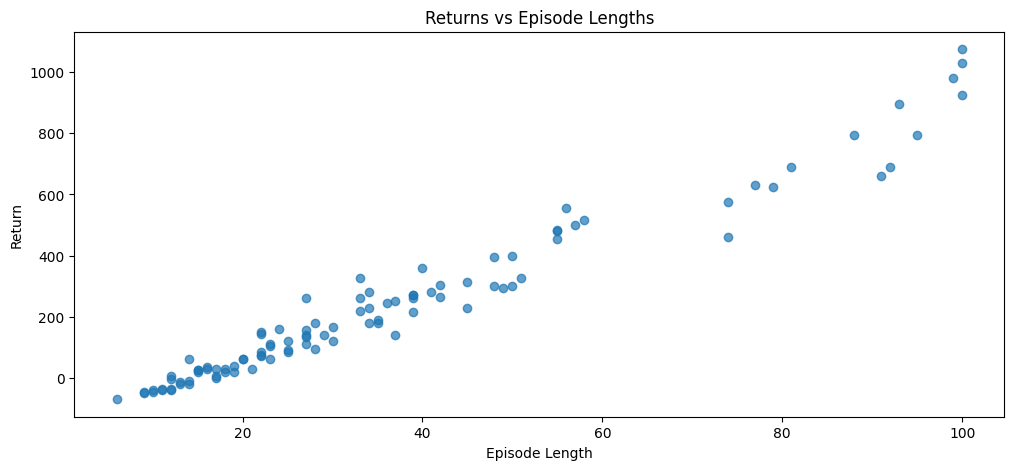

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(lengths, total_returns, 'o', alpha=0.7)
plt.title("Returns vs Episode Lengths")
plt.xlabel("Episode Length")
plt.ylabel("Return")
plt.show()

In [42]:
env = BlockBlastEnv(render_mode="rgb_array")
obs, info = env.reset()

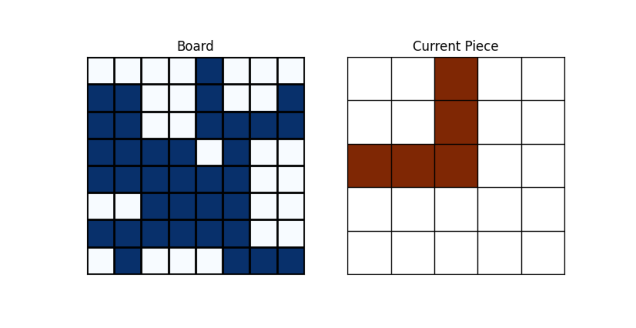


Game Terminated.

Final Reward: 75.0


In [ ]:


obs, info = env.reset()
STEPS = 20
total_reward = 0

for step_idx in range(STEPS):
    # Render the rgb_array
    img = env.render()
    
    # Clear previous frame and draw new one
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    print(f"--- Step {step_idx + 1} ---")
    print(f"Current Total Reward: {total_reward}")
    x = torch.tensor(obs["board"], dtype=torch.float32).unsqueeze(0).to(agent.device)
    print(f"Agent value estimation: {agent.policy_net(x).cpu().detach().numpy()}")
    
    action = agent.select_action(obs, epsilon=0.0)
    #rewards = obs["placements_result"][1]
    #action = np.argmax(rewards)
    
    # Step
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    
    time.sleep(0.5)
    
    if terminated or truncated:
        # Last render on termination
        img = env.render()
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        print("\nGame Terminated.")
        break

print(f"\nFinal Reward: {total_reward}")
env.close()